# Python in Biology: Morning Instructor Notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hezhaobin/2026-summer-coding-workshop/blob/dev/notebooks/morning/00_instructor_complete.ipynb)

**Workshop time:** 9:30 a.m.–12:30 p.m.  
**Biological question:** What can a protein sequence tell us about whether a fungal protein might act as an adhesin?

This minimal instructor notebook is both the activity guide and the handout. Run cells from top to bottom. The two example sequences and all required calculations are embedded, so the coding portion works even if a prediction server is unavailable.


## Morning roadmap

| Time | Activity |
| --- | --- |
| 9:30–9:40 | Colab orientation and learning goals |
| 9:40–10:00 | What is a fungal adhesin? |
| 10:00–10:30 | Examine ALS1 and PHO84 with SignalP and NetGPI |
| 10:30–11:30 | Python refresher and whole-protein S/T frequency |
| 11:30–11:45 | Break |
| 11:45–12:15 | Sliding-window S/T frequency |
| 12:15–12:30 | From two proteins to a table |

By lunch, you should be able to:

1. explain what SignalP and NetGPI predict;
2. calculate the fraction of serine (S) and threonine (T) in a protein;
3. explain why a sliding window can reveal a local S/T-rich region;
4. describe why these clues suggest, but do not prove, adhesin function.


## 1. Colab orientation — Read, then run

A notebook contains **text cells** like this one and **code cells** like the next one. Click the run button beside a code cell. The number beside it records execution order.

When testing this notebook in Colab, choose **File → Save a copy in Drive** before editing. If the notebook state becomes confusing, choose **Runtime → Restart session**, then run from the top.


In [1]:
workshop_message = "Sequence clues can guide a biological hypothesis."
print(workshop_message)


Sequence clues can guide a biological hypothesis.


## 2. What is a fungal adhesin? — Read

Fungal adhesins help cells attach to host tissue, other microbes, or surfaces. Many well-studied adhesins travel through the secretory pathway and become attached to the cell wall.

A common—but not universal—adhesin architecture includes:

- an **N-terminal signal peptide** that sends the new protein into the secretory pathway;
- an **adhesive or effector domain** that interacts with another surface;
- a long, often **serine/threonine-rich stalk** that can be heavily glycosylated;
- sometimes **tandem repeats**;
- a **C-terminal GPI-anchor signal** that can lead to cell-wall attachment.

These are clues, not a checklist that proves adhesion. Other cell-wall proteins may share several of them.

### Predict before using a server

We will compare *Candida albicans* ALS1, a characterized adhesin, with PHO84, a multi-pass phosphate transporter. Which protein do you expect to have a cleavable signal peptide, a GPI-anchor signal, and a high S/T frequency? Explain your prediction before continuing.


## 3. Embedded example sequences — Read and copy

These FASTA records come from the frozen *C. albicans* SC5314 UniProt reference proteome `UP000000559`, release `2026_02`. Their original headers and residues are retained here for copying into SignalP and NetGPI.

### ALS1

```fasta
>sp|Q5A8T4|ALS1_CANAL Agglutinin-like protein 1 OS=Candida albicans (strain SC5314 / ATCC MYA-2876) OX=237561 GN=ALS1 PE=1 SV=1
MLQQFTLLFLYLSIASAKTITGVFDSFNSLTWSNAANYAFKGPGYPTWNAVLGWSLDGTSANPGDTFTLNMPCVFKYTTS
QTSVDLTADGVKYATCQFYSGEEFTTFSTLTCTVNDALKSSIKAFGTVTLPIAFNVGGTGSSTDLEDSKCFTAGTNTVTF
NDGDKDISIDVEFEKSTVDPSGYLYASRVMPSLNKVTTLFVAPQCENGYTSGTMGFSSSNGDVAIDCSNIHIGITKGLND
WNYPVSSESFSYTKTCTSNGIQIKYQNVPAGYRPFIDAYISATDVNQYTLAYTNDYTCAGSRSQSKPFTLRWTGYKNSDA
GSNGIVIVATTRTVTDSTTAVTTLPFNPSVDKTKTIEILQPIPTTTITTSYVGVTTSYSTKTAPIGETATVIVDVPYHTT
TTVTSEWTGTITTTTTRTNPTDSIDTVVVQVPSPNPTVSTTEYWSQSYATTTTVTAPPGGTDTVIIREPPNHTVTTTEYW
SQSFATTTTVTAPPGETDTVIIREPPNHTVTTTEYWSQSYATTTTVTAPPGGTDTVLIREPPNHTVTTTEYWSQSYATTT
TVTAPPGGTDTVIIREPPNYTVTTTEYWSQSYATTTTITAPPGETDTVIIREPPNHTVTTTEYWSQSYATTTTVTAPPGG
TDTVLIREPPNHTVTTTEYWSQSYATTTTVTAPPGGTDTVLIREPPNHTVTTTEYWSQSYATTTTVTAPPGGTDTVIIRE
PPNHTVTTTEYWSQSYATTTTVTAPPGGTDTVIIREPPNYTVTTTEYWSQSFATTTTVTAPPGGTDTVIIYESMSSSKIS
TSSNDITSIIPSFSRPHYVNSTTSDLSTFESSSMNTPTSISSDGMLLSSTTLVTESETTTESICSDGKECSRLSSSSGIV
TNPDSNESSIVTSTVPTASTMSDSLSSTDGISATSSDNVSKSGVSVTTETSVTTIQTTPNPLSSSVTSLTQLSSIPSVSE
SESKVTFTSNGDNQSGTHDSQSTSTEIEIVTTSSTKVLPPVVSSNTDLTSEPTNTREQPTTLSTTSNSITEDITTSQPTG
DNGDNTSSTNPVPTVATSTLASASEEDNKSGSHESASTSLKPSMGENSGLTTSTEIEATTTSPTEAPSPAVSSGTDVTTE
PTDTREQPTTLSTTSKTNSESVATTQATNENGGKSPSTDLTSSLTTGTSASTSANSELVTSGSVTGGAVASASNDQSHST
SVTNSNSIVSNTPQTTLSQQVTSSSPSTNTFIASTYDGSGSIIQHSTWLYGLITLLSLFI
```

### PHO84

```fasta
>tr|A0A1D8PF54|A0A1D8PF54_CANAL Phosphate transporter OS=Candida albicans (strain SC5314 / ATCC MYA-2876) OX=237561 GN=PHO84 PE=4 SV=1
MKYPKVXGKTAFKDYLGKFADVEDPLERRRLALEEIDKAGFGWTQVKMILIAGVGFMTDSYDIFAINLSMNMLQYVYWNG
TIPDSTTTLIKVSTSVGTVIGQISFGSIADKVGRKKIYGLELIIMIFATLFQCTLGTSPAINFVAIFSTIRILMGIGIGG
DYPLSSIISSEFSTTKWRGAIMAAVFSNQGLGQVFAGIVAMICVAGYKDDLIIANKGSECVGRCRKAADQMWRIIVGFGC
VPGCIALYYRLTIAESPRYALDVDEHDDLEKVADAEAAIDVHAQEIAPPKASFKDFCSHFGQWRYGKILLGTAGSWFMLD
VAYYGLGLNTTTILQTIGYAGQSNVYEKLYNSAAGNLILVCAGSLPGYWVSAATIDTVGRKPIQMGGFILLTIILCIMGF
GYHKIGNHGLLGLFVIAQFFQNFGPNTTTFIVPGECFPTRYRSTAHGLSAAAGKVGAIIAQTCIGTLVNHGCSKENKNCF
LPHVLEIFALFMLLGIGLTFLIPETARRTLEEISETCHGEVDTTKLGRDRFATQEEPYDSEEVKN
```


In [2]:
als1_sequence = (
    "MLQQFTLLFLYLSIASAKTITGVFDSFNSLTWSNAANYAFKGPGYPTWNAVLGWSLDGTSANPGDTFTLNMPCVFKYTTS"
    "QTSVDLTADGVKYATCQFYSGEEFTTFSTLTCTVNDALKSSIKAFGTVTLPIAFNVGGTGSSTDLEDSKCFTAGTNTVTF"
    "NDGDKDISIDVEFEKSTVDPSGYLYASRVMPSLNKVTTLFVAPQCENGYTSGTMGFSSSNGDVAIDCSNIHIGITKGLND"
    "WNYPVSSESFSYTKTCTSNGIQIKYQNVPAGYRPFIDAYISATDVNQYTLAYTNDYTCAGSRSQSKPFTLRWTGYKNSDA"
    "GSNGIVIVATTRTVTDSTTAVTTLPFNPSVDKTKTIEILQPIPTTTITTSYVGVTTSYSTKTAPIGETATVIVDVPYHTT"
    "TTVTSEWTGTITTTTTRTNPTDSIDTVVVQVPSPNPTVSTTEYWSQSYATTTTVTAPPGGTDTVIIREPPNHTVTTTEYW"
    "SQSFATTTTVTAPPGETDTVIIREPPNHTVTTTEYWSQSYATTTTVTAPPGGTDTVLIREPPNHTVTTTEYWSQSYATTT"
    "TVTAPPGGTDTVIIREPPNYTVTTTEYWSQSYATTTTITAPPGETDTVIIREPPNHTVTTTEYWSQSYATTTTVTAPPGG"
    "TDTVLIREPPNHTVTTTEYWSQSYATTTTVTAPPGGTDTVLIREPPNHTVTTTEYWSQSYATTTTVTAPPGGTDTVIIRE"
    "PPNHTVTTTEYWSQSYATTTTVTAPPGGTDTVIIREPPNYTVTTTEYWSQSFATTTTVTAPPGGTDTVIIYESMSSSKIS"
    "TSSNDITSIIPSFSRPHYVNSTTSDLSTFESSSMNTPTSISSDGMLLSSTTLVTESETTTESICSDGKECSRLSSSSGIV"
    "TNPDSNESSIVTSTVPTASTMSDSLSSTDGISATSSDNVSKSGVSVTTETSVTTIQTTPNPLSSSVTSLTQLSSIPSVSE"
    "SESKVTFTSNGDNQSGTHDSQSTSTEIEIVTTSSTKVLPPVVSSNTDLTSEPTNTREQPTTLSTTSNSITEDITTSQPTG"
    "DNGDNTSSTNPVPTVATSTLASASEEDNKSGSHESASTSLKPSMGENSGLTTSTEIEATTTSPTEAPSPAVSSGTDVTTE"
    "PTDTREQPTTLSTTSKTNSESVATTQATNENGGKSPSTDLTSSLTTGTSASTSANSELVTSGSVTGGAVASASNDQSHST"
    "SVTNSNSIVSNTPQTTLSQQVTSSSPSTNTFIASTYDGSGSIIQHSTWLYGLITLLSLFI"
)

pho84_sequence = (
    "MKYPKVXGKTAFKDYLGKFADVEDPLERRRLALEEIDKAGFGWTQVKMILIAGVGFMTDSYDIFAINLSMNMLQYVYWNG"
    "TIPDSTTTLIKVSTSVGTVIGQISFGSIADKVGRKKIYGLELIIMIFATLFQCTLGTSPAINFVAIFSTIRILMGIGIGG"
    "DYPLSSIISSEFSTTKWRGAIMAAVFSNQGLGQVFAGIVAMICVAGYKDDLIIANKGSECVGRCRKAADQMWRIIVGFGC"
    "VPGCIALYYRLTIAESPRYALDVDEHDDLEKVADAEAAIDVHAQEIAPPKASFKDFCSHFGQWRYGKILLGTAGSWFMLD"
    "VAYYGLGLNTTTILQTIGYAGQSNVYEKLYNSAAGNLILVCAGSLPGYWVSAATIDTVGRKPIQMGGFILLTIILCIMGF"
    "GYHKIGNHGLLGLFVIAQFFQNFGPNTTTFIVPGECFPTRYRSTAHGLSAAAGKVGAIIAQTCIGTLVNHGCSKENKNCF"
    "LPHVLEIFALFMLLGIGLTFLIPETARRTLEEISETCHGEVDTTKLGRDRFATQEEPYDSEEVKN"
)

print("ALS1 and PHO84 sequences are ready for analysis.")


ALS1 and PHO84 sequences are ready for analysis.


### Provided sequence checks — Run

The example variables contain amino-acid residues only—no FASTA headers. `X` is allowed because the frozen PHO84 sequence contains one unknown residue.


In [3]:
VALID_RESIDUES = set("ACDEFGHIKLMNPQRSTVWYX")


def check_protein_sequence(sequence):
    invalid_residues = set(sequence) - VALID_RESIDUES
    if invalid_residues:
        raise ValueError(f"Unexpected residues: {sorted(invalid_residues)}")


check_protein_sequence(als1_sequence)
check_protein_sequence(pho84_sequence)

assert len(als1_sequence) == 1260
assert len(pho84_sequence) == 545
assert pho84_sequence[6] == "X"

print(f"ALS1 length: {len(als1_sequence)} amino acids")
print(f"PHO84 length: {len(pho84_sequence)} amino acids")
print("The embedded sequences passed their checks.")


ALS1 length: 1260 amino acids
PHO84 length: 545 amino acids
The embedded sequences passed their checks.


## 4. SignalP 6.0 activity — Student action

Open [SignalP 6.0](https://services.healthtech.dtu.dk/services/SignalP-6.0/).

1. Copy and paste the ALS1 and PHO84 FASTA records from the Markdown sequence blocks.
2. Choose **Eukarya**.
3. Choose **Long/standard output**.
4. Use **Fast** mode for this workshop.
5. Submit the sequences.
6. Record the predicted class, signal-peptide probability, and cleavage site when reported.

Discuss:

- Which sequence has a predicted cleavable N-terminal signal peptide?
- What does an “Other” call mean?
- How is a cleavable signal peptide different from a transmembrane helix?
- Does a signal peptide prove that a protein is an adhesin?

**If SignalP is unavailable:** open the [saved SignalP demo results](https://github.com/hezhaobin/2026-summer-coding-workshop/blob/main/docs/demo-predictor-results.md#signalp-60). Have students use the saved table and plots to record the same prediction, probability, and cleavage-site fields. The complete saved webpage and machine-readable raw outputs are retained on `dev` under `input/raw/predictors/demo/20260811-signalp-6.0/`.


## 5. NetGPI 1.1 activity — Student action

Open [NetGPI 1.1](https://services.healthtech.dtu.dk/services/NetGPI-1.1/).

NetGPI is most meaningful after there is evidence that a protein enters the secretory pathway. It examines the C-terminal region for a possible GPI-anchor signal.

1. Submit **ALS1** using long output.
2. Record the binary GPI-anchor call and predicted omega site, if present.
3. Notice the sentinel `*` used by the service when displaying the sequence end.
4. Do not treat PHO84 as an automatic second submission. First ask whether its SignalP result and transporter architecture support the biological assumptions behind NetGPI.

Discuss:

- What would a positive GPI-anchor prediction imply about localization?
- Why should SignalP or equivalent evidence be considered first?
- Could a non-adhesin cell-wall protein also receive positive SignalP and GPI-anchor predictions?

**If NetGPI is unavailable:** open the [saved NetGPI demo results](https://github.com/hezhaobin/2026-summer-coding-workshop/blob/main/docs/demo-predictor-results.md#netgpi-11). Have students use the saved table and plots to record the GPI-anchor call, reported likelihood, and omega site. The complete saved webpage and machine-readable raw outputs are retained on `dev` under `input/raw/predictors/demo/20260811-netgpi-1.1/`.


## 6. Python refresher: whole-protein S/T frequency

For a protein sequence,

`st_frequency = (count(S) + count(T)) / protein_length`

First use a sequence with an answer you can calculate by hand.

### Predict

For `tiny_sequence = "MASTT"`:

- What is its length?
- How many residues are S or T?
- What fraction of the sequence is S or T?


In [4]:
tiny_sequence = "MASTT"

print("Length:", len(tiny_sequence))
print("S count:", tiny_sequence.count("S"))
print("T count:", tiny_sequence.count("T"))


Length: 5
S count: 1
T count: 2


### Exercise M1: whole-protein S/T frequency — Instructor solution

For an empty sequence, the frequency is missing rather than zero because there is no denominator. The function returns `None`. Unknown residue `X` remains part of protein length but does not count as S or T.


In [5]:
def st_frequency(sequence):
    protein_length = len(sequence)

    if protein_length == 0:
        return None

    st_count = sequence.count("S") + sequence.count("T")
    return st_count / protein_length


assert st_frequency("MASTT") == 3 / 5
assert st_frequency("AAAA") == 0
assert st_frequency("") is None

print("Tiny-sequence S/T frequency:", st_frequency(tiny_sequence))
print("All whole-protein tests passed.")


Tiny-sequence S/T frequency: 0.6
All whole-protein tests passed.


In [6]:
als1_st_frequency = st_frequency(als1_sequence)
pho84_st_frequency = st_frequency(pho84_sequence)

print(f"ALS1 whole-protein S/T frequency:  {als1_st_frequency:.3f}")
print(f"PHO84 whole-protein S/T frequency: {pho84_st_frequency:.3f}")


ALS1 whole-protein S/T frequency:  0.368
PHO84 whole-protein S/T frequency: 0.123


## Break — 11:30–11:45

When you return, restart here. The next idea asks whether a protein contains a **local** S/T-rich region even when its whole-protein average is modest.


## 7. Exercise M2: sliding-window S/T frequency

A window is a short, contiguous part of a sequence. With a window size of 4, the first two overlapping windows of `MASTTA` are `MAST` and `ASTT`. Moving one residue at a time means the windows overlap.

Our function will:

1. examine every overlapping window;
2. calculate each window’s S/T frequency;
3. return the largest frequency.

Documented behavior:

- an empty sequence returns `None`;
- a sequence shorter than the requested window uses the whole sequence as one window;
- windows move one residue at a time and therefore overlap;
- ties do not change the returned maximum frequency;
- residues other than S and T remain in the denominator.


In [7]:
def max_st_frequency_window(sequence, window_size=50):
    if len(sequence) == 0:
        return None

    if window_size <= 0:
        raise ValueError("window_size must be greater than zero")

    if len(sequence) <= window_size:
        return st_frequency(sequence)

    maximum_frequency = 0

    last_start = len(sequence) - window_size
    for start in range(last_start + 1):
        window = sequence[start:start + window_size]
        window_frequency = st_frequency(window)

        if window_frequency > maximum_frequency:
            maximum_frequency = window_frequency

    return maximum_frequency


assert max_st_frequency_window("MASTTA", 4) == 3 / 4
assert max_st_frequency_window("ST", 50) == 1
assert max_st_frequency_window("") is None

print("All sliding-window tests passed.")


All sliding-window tests passed.


In [8]:
WINDOW_SIZE = 50

als1_max_st = max_st_frequency_window(als1_sequence, WINDOW_SIZE)
pho84_max_st = max_st_frequency_window(pho84_sequence, WINDOW_SIZE)

print(f"ALS1 maximum {WINDOW_SIZE}-residue S/T frequency:  {als1_max_st:.3f}")
print(f"PHO84 maximum {WINDOW_SIZE}-residue S/T frequency: {pho84_max_st:.3f}")


ALS1 maximum 50-residue S/T frequency:  0.540
PHO84 maximum 50-residue S/T frequency: 0.280


## 8. From two proteins to a table — Run

The dataframe and plotting syntax below are provided infrastructure. Focus on interpreting the biological pattern rather than memorizing Pandas or plotting commands.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

protein_features = pd.DataFrame(
    {
        "protein": ["ALS1", "PHO84"],
        "teaching_role": ["known adhesin", "phosphate transporter"],
        "protein_length": [len(als1_sequence), len(pho84_sequence)],
        "st_frequency": [als1_st_frequency, pho84_st_frequency],
        "max_st_frequency_window_50": [als1_max_st, pho84_max_st],
    }
)

protein_features


,protein,teaching_role,protein_length,st_frequency,max_st_frequency_window_50
0,ALS1,known adhesin,1260,0.368254,0.54
1,PHO84,phosphate transporter,545,0.122936,0.28


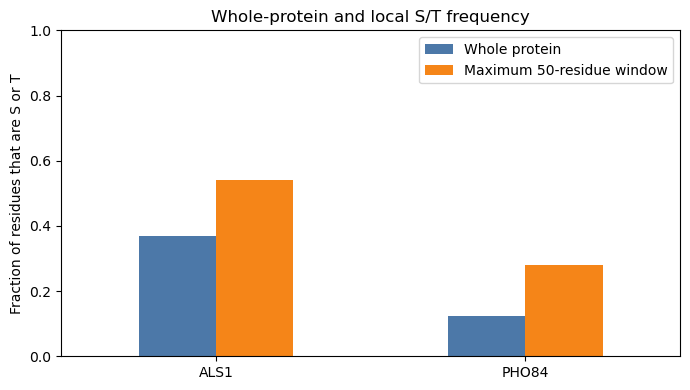

In [10]:
plot_data = protein_features.set_index("protein")[[
    "st_frequency",
    "max_st_frequency_window_50",
]]

ax = plot_data.plot(kind="bar", figsize=(7, 4), color=["#4C78A8", "#F58518"])
ax.set_ylabel("Fraction of residues that are S or T")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.set_title("Whole-protein and local S/T frequency")
ax.legend(["Whole protein", "Maximum 50-residue window"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Provided infrastructure: load a frozen proteome with Biopython

Students will not write the download or FASTA-parsing code. The two provided cells below:

1. prepare Biopython in Colab;
2. download the frozen *C. albicans* SC5314 FASTA from this repository;
3. verify its SHA-256 checksum;
4. parse the downloaded local file with Biopython.

The GitHub file is a frozen workshop input, not a live UniProt query. If GitHub is unavailable, upload the instructor-provided backup FASTA through Colab’s **Files** panel and rerun the loading cell.


In [11]:
#@title Prepare Biopython { display-mode: "form" }

from pathlib import Path
import importlib.util
import subprocess
import sys

if Path("/content").exists():
    if importlib.util.find_spec("Bio") is None:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "--quiet", "biopython==1.87"],
            check=True,
        )
    print("Biopython is ready.")
else:
    print("Biopython setup is skipped outside a Colab runtime.")


Biopython setup is skipped outside a Colab runtime.


In [12]:
from pathlib import Path
from urllib.request import urlretrieve
import hashlib

PROTEOME_FILENAME = "UP000000559-uniprot-2026_02.fasta"
PROTEOME_URL = (
    "https://raw.githubusercontent.com/hezhaobin/"
    "2026-summer-coding-workshop/main/input/raw/proteomes/"
    "candida_albicans_sc5314/UP000000559-uniprot-2026_02.fasta"
)
EXPECTED_SHA256 = "518a55bfe7d05e966d9a34b865b8bb3ca17001535076bccad84d65582a871c61"
COLAB_CONTENT = Path("/content")

if not COLAB_CONTENT.exists():
    print("Remote proteome loading is skipped outside a Colab runtime.")
else:
    proteome_fasta = COLAB_CONTENT / PROTEOME_FILENAME

    if not proteome_fasta.exists():
        try:
            urlretrieve(PROTEOME_URL, proteome_fasta)
            print("Downloaded the frozen SC5314 proteome from the workshop repository.")
        except Exception as error:
            print("Automatic download failed:", error)
            print("Upload the instructor-provided FASTA with Colab's Files panel.")

    if proteome_fasta.exists():
        observed_sha256 = hashlib.sha256(proteome_fasta.read_bytes()).hexdigest()
        if observed_sha256 != EXPECTED_SHA256:
            raise ValueError("The proteome FASTA checksum does not match the frozen workshop file.")

        from Bio import SeqIO

        proteome_records = list(SeqIO.parse(proteome_fasta, "fasta"))
        print(f"Loaded {len(proteome_records)} protein records.")
        print("First protein ID:", proteome_records[0].id)


Remote proteome loading is skipped outside a Colab runtime.


## 10. Morning synthesis — Discuss

1. Which sequence feature most clearly separates ALS1 from PHO84 in this two-protein comparison?
2. Why can the maximum-window value be more informative than the whole-protein value?
3. Why do SignalP, NetGPI, and S/T enrichment still not prove that a protein is an adhesin?
4. What experimental observation would provide stronger evidence of adhesion?

### Takeaway

Protein sequence can provide several biologically interpretable clues about trafficking, cell-surface attachment, and glycosylated stalk regions. Combining clues is more useful than relying on one feature, but computational predictions remain hypotheses that require biological validation.

### Recovery notes

- If a live server is slow or unavailable, use the qualitative backup interpretations and continue with the embedded sequences.
- If code cells were run out of order, restart the runtime and run from the top.
- The coding exercises require no Drive mount, live download, or external data file.
